In [5]:
# 1. Import Libraries
# 2. Load Dataset
# 3. Data Cleaning
# 4. Feature Engineering
# 5. Train-Test Split
# ==========================================================

import os
import warnings
import joblib
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

print("="*80)
print("CONFIGURING PROJECT")
print("="*80)

PROJECT_ROOT = r"C:\Users\User\OneDrive\Documents\IoT-Based-Intelligent-Building-DSS"

DATA_PATH = os.path.join(
    PROJECT_ROOT,
    "data",
    "processed",
    "smart_building_validation_dataset.csv"
)

print("Dataset Exists :", os.path.exists(DATA_PATH))

print("="*80)
print("LOADING DATASET")
print("="*80)

df = pd.read_csv(DATA_PATH)

print("Original Shape :", df.shape)

# ==========================================================
# Remove Duplicate Records
# ==========================================================

duplicates = df.duplicated().sum()

print("\nDuplicate Records :", duplicates)

df.drop_duplicates(inplace=True)

# ==========================================================
# Missing Values
# ==========================================================

print("\nMissing Values Before Cleaning")

print(df.isnull().sum())

# Remove rows where target is missing
df = df.dropna(subset=["electricity_total"])

# Fill numerical missing values

numerical_columns = df.select_dtypes(include=np.number).columns

for column in numerical_columns:

    df[column] = df[column].fillna(df[column].median())

print("\nMissing Values After Cleaning")

print(df.isnull().sum())

# ==========================================================
# Datetime Features
# ==========================================================

df["datetime"] = pd.to_datetime(df["datetime"])

df["year"] = df["datetime"].dt.year

df["month"] = df["datetime"].dt.month

df["day"] = df["datetime"].dt.day

df["hour"] = df["datetime"].dt.hour

df["day_of_week"] = df["datetime"].dt.dayofweek

df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

df["week_of_year"] = df["datetime"].dt.isocalendar().week.astype(int)

df["quarter"] = df["datetime"].dt.quarter

print("\nDatetime Features Created Successfully")

# ==========================================================
# Features
# ==========================================================

feature_columns = [

    "year",

    "month",

    "day",

    "hour",

    "day_of_week",

    "is_weekend",

    "week_of_year",

    "quarter",

    "solar_irradiance",

    "air_temperature",

    "PV",

    "CHP",

    "total_cooling",

    "cool_elec",

    "total_heating",

    "CHP_heat",

    "CHP_elec"

]

target = "electricity_total"

X = df[feature_columns]

y = df[target]

print("="*80)
print("DATASET READY")
print("="*80)

print("Features :", X.shape)

print("Target :", y.shape)

# ==========================================================
# Train Test Split
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42

)

print("="*80)
print("TRAIN TEST SPLIT")
print("="*80)

print("Training :", X_train.shape)

print("Testing :", X_test.shape)

# ==========================================================
# Save Split
# ==========================================================

MODEL_DIR = os.path.join(PROJECT_ROOT, "models")

os.makedirs(MODEL_DIR, exist_ok=True)

train_data = X_train.copy()
train_data["electricity_total"] = y_train

test_data = X_test.copy()
test_data["electricity_total"] = y_test

train_data.to_csv(
    os.path.join(MODEL_DIR, "secondary_train_dataset.csv"),
    index=False
)

test_data.to_csv(
    os.path.join(MODEL_DIR, "secondary_test_dataset.csv"),
    index=False
)

print("\nTraining and Testing datasets saved successfully")

print("="*80)
print("CELL 1 COMPLETED")
print("="*80)

CONFIGURING PROJECT
Dataset Exists : True
LOADING DATASET
Original Shape : (52608, 17)

Duplicate Records : 0

Missing Values Before Cleaning
datetime_utc             0
electricity_total       24
PV                   13079
CHP                     24
solar_irradiance      1234
air_temperature       1234
total_cooling           24
cool_elec               24
datetime                24
date                    24
year                    24
month                   24
day                     24
hour                    24
total_heating           24
CHP_heat                24
CHP_elec                24
dtype: int64

Missing Values After Cleaning
datetime_utc         0
electricity_total    0
PV                   0
CHP                  0
solar_irradiance     0
air_temperature      0
total_cooling        0
cool_elec            0
datetime             0
date                 0
year                 0
month                0
day                  0
hour                 0
total_heating        0
CHP_heat  

In [6]:
# ==========================================================
# SECONDARY SMART BUILDING PREDICTION
# Cell 2
# 6. Train Regression Models
# 7. Model Evaluation
# 8. Performance Comparison
# 9. Best Model Selection
# 10. Save Results
# ==========================================================

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("="*80)
print("TRAINING REGRESSION MODELS")
print("="*80)

# ==========================================================
# Models
# ==========================================================

models = {

    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),

    "Extra Trees": ExtraTreesRegressor(
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBRegressor(
        random_state=42,
        objective="reg:squarederror",
        tree_method="hist"
    )

}

results = []

trained_models = {}

# ==========================================================
# Training Loop
# ==========================================================

for name, model in models.items():

    print(f"\nTraining {name}...")

    model.fit(X_train, y_train)

    trained_models[name] = model

    train_pred = model.predict(X_train)

    test_pred = model.predict(X_test)

    train_mae = mean_absolute_error(y_train, train_pred)
    test_mae = mean_absolute_error(y_test, test_pred)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    train_mape = np.mean(
        np.abs((y_train-train_pred)/y_train)
    )*100

    test_mape = np.mean(
        np.abs((y_test-test_pred)/y_test)
    )*100

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    results.append([

        name,

        train_mae,
        test_mae,

        train_rmse,
        test_rmse,

        train_mape,
        test_mape,

        train_r2,
        test_r2

    ])

    print(f"{name} Completed")

print("="*100)
print("MODEL PERFORMANCE COMPARISON")
print("="*100)

results_df = pd.DataFrame(

    results,

    columns=[

        "Model",

        "Train MAE",
        "Test MAE",

        "Train RMSE",
        "Test RMSE",

        "Train MAPE",
        "Test MAPE",

        "Train R2",
        "Test R2"

    ]

)

results_df = results_df.sort_values(

    by="Test R2",

    ascending=False

).reset_index(drop=True)

display(results_df)

# ==========================================================
# Save Model Comparison
# ==========================================================

results_df.to_csv(

    os.path.join(

        MODEL_DIR,

        "secondary_model_comparison.csv"

    ),

    index=False

)

# ==========================================================
# Best Model
# ==========================================================

best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]

print("="*80)
print("BEST MODEL")
print("="*80)

print("Best Model :", best_model_name)

print("Test R2 :", results_df.iloc[0]["Test R2"])

print("Test RMSE :", results_df.iloc[0]["Test RMSE"])

print("Test MAE :", results_df.iloc[0]["Test MAE"])

print("="*80)
print("CELL 2 COMPLETED")
print("="*80)

TRAINING REGRESSION MODELS

Training Linear Regression...
Linear Regression Completed

Training Random Forest...
Random Forest Completed

Training Gradient Boosting...
Gradient Boosting Completed

Training Extra Trees...
Extra Trees Completed

Training XGBoost...
XGBoost Completed
MODEL PERFORMANCE COMPARISON


,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train MAPE,Test MAPE,Train R2,Test R2
0,Extra Trees,4.290647e-10,19811.213683,3.117074e-08,30884.513479,2.047000e-13,34.557743,1.000000,0.936678
1,XGBoost,1.889991e+04,22391.862706,2.682548e+04,32366.599793,4.471181e+01,47.116924,0.952294,0.930455
2,Random Forest,8.460150e+03,22159.809027,1.297852e+04,33628.011247,2.251541e+01,40.526875,0.988833,0.924929
3,Gradient Boosting,3.131935e+04,31123.292558,4.370385e+04,43448.526409,8.911460e+01,80.204331,0.873375,0.874680
4,Linear Regression,4.459223e+04,43897.619297,5.933306e+04,58310.788207,1.162324e+02,121.285644,0.766614,0.774281


BEST MODEL
Best Model : Extra Trees
Test R2 : 0.93667847669074
Test RMSE : 30884.51347920185
Test MAE : 19811.213683128364
CELL 2 COMPLETED


In [7]:
# ==========================================================
# SECONDARY SMART BUILDING PREDICTION
# Cell 3
# 11. Hyperparameter Tuning
# 12. Best Model Selection
# 13. Prediction
# 14. Model Saving
# 15. Prediction Report
# ==========================================================

from sklearn.model_selection import GridSearchCV

print("="*80)
print("HYPERPARAMETER TUNING")
print("="*80)

# ==========================================================
# Top Models
# ==========================================================

tuning_models = {

    "Random Forest": RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesRegressor(
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBRegressor(
        random_state=42,
        objective="reg:squarederror",
        tree_method="hist"
    )

}

# ==========================================================
# Parameter Grid
# ==========================================================

param_grid = {

    "n_estimators":[50,100,150],

    "max_depth":[5,10,None]

}

best_models = {}

tuned_results = []

# ==========================================================
# Grid Search
# ==========================================================

for name, model in tuning_models.items():

    print(f"\nTuning {name}")

    valid_params = {

        k:v

        for k,v in param_grid.items()

        if k in model.get_params()

    }

    grid = GridSearchCV(

        estimator=model,

        param_grid=valid_params,

        cv=3,

        scoring="r2",

        n_jobs=-1,

        verbose=2

    )

    grid.fit(

        X_train,

        y_train

    )

    best_models[name] = grid.best_estimator_

    prediction = grid.best_estimator_.predict(X_test)

    tuned_results.append([

        name,

        grid.best_score_,

        mean_absolute_error(
            y_test,
            prediction
        ),

        np.sqrt(
            mean_squared_error(
                y_test,
                prediction
            )
        ),

        np.mean(
            np.abs(
                (y_test-prediction)/y_test
            )
        )*100,

        r2_score(
            y_test,
            prediction
        ),

        grid.best_params_

    ])

# ==========================================================
# Results
# ==========================================================

tuned_df = pd.DataFrame(

    tuned_results,

    columns=[

        "Model",

        "CV R2",

        "MAE",

        "RMSE",

        "MAPE",

        "Test R2",

        "Best Parameters"

    ]

)

tuned_df = tuned_df.sort_values(

    by="Test R2",

    ascending=False

).reset_index(drop=True)

print("="*100)
print("TUNED MODEL COMPARISON")
print("="*100)

display(tuned_df)

# ==========================================================
# Final Model
# ==========================================================

best_model_name = tuned_df.iloc[0]["Model"]

final_model = best_models[best_model_name]

print("="*80)
print("FINAL MODEL")
print("="*80)

print(best_model_name)

# ==========================================================
# Save Model
# ==========================================================

joblib.dump(

    final_model,

    os.path.join(

        MODEL_DIR,

        "secondary_best_model.pkl"

    )

)

print("\nModel Saved Successfully")

# ==========================================================
# Prediction
# ==========================================================

prediction = final_model.predict(X_test)

prediction_df = pd.DataFrame({

    "Actual":y_test,

    "Predicted":prediction

})

prediction_df["Difference"] = (

    prediction_df["Actual"]

    -

    prediction_df["Predicted"]

)

prediction_df["Absolute Error"] = np.abs(

    prediction_df["Difference"]

)

prediction_df["Percentage Error"] = (

    prediction_df["Absolute Error"]

    /

    prediction_df["Actual"]

)*100

display(

    prediction_df.head(10)

)

prediction_df.to_csv(

    os.path.join(

        MODEL_DIR,

        "secondary_predictions.csv"

    ),

    index=False

)

print("="*80)
print("Average Prediction Accuracy")
print("="*80)

accuracy = (

    100

    -

    prediction_df["Percentage Error"].mean()

)

print(

    round(

        accuracy,

        2

    ),

    "%"

)

print("="*80)
print("CELL 3 COMPLETED")
print("="*80)

HYPERPARAMETER TUNING

Tuning Random Forest
Fitting 3 folds for each of 9 candidates, totalling 27 fits

Tuning Extra Trees
Fitting 3 folds for each of 9 candidates, totalling 27 fits

Tuning XGBoost
Fitting 3 folds for each of 9 candidates, totalling 27 fits
TUNED MODEL COMPARISON


,Model,CV R2,MAE,RMSE,MAPE,Test R2,Best Parameters
0,XGBoost,0.926231,19900.080773,30134.134684,38.344257,0.939718,"{'max_depth': 10, 'n_estimators': 150}"
1,Extra Trees,0.923522,19746.551651,30744.903469,34.277591,0.937250,"{'max_depth': None, 'n_estimators': 150}"
2,Random Forest,0.913379,22112.114651,33539.856260,40.364627,0.925322,"{'max_depth': None, 'n_estimators': 150}"


FINAL MODEL
XGBoost

Model Saved Successfully


,Actual,Predicted,Difference,Absolute Error,Percentage Error
29194,-105598.353622,-63502.828125,-42095.525497,42095.525497,-39.863809
25140,247330.643938,158749.921875,88580.722063,88580.722063,35.814698
12814,250945.692336,229561.937500,21383.754836,21383.754836,8.521268
43014,154052.911378,174494.203125,-20441.291747,20441.291747,13.269007
5677,408177.617744,399463.750000,8713.867744,8713.867744,2.134823
15388,38690.779708,29585.716797,9105.062911,9105.062911,23.532901
39252,231426.851396,245141.953125,-13715.101729,13715.101729,5.926323
25893,173166.278958,175886.468750,-2720.189792,2720.189792,1.570854
49463,301343.976034,268325.718750,33018.257284,33018.257284,10.956999
46515,93336.723158,82697.492188,10639.230970,10639.230970,11.398762


Average Prediction Accuracy
91.77 %
CELL 3 COMPLETED


In [8]:
# ==========================================================
# SECONDARY SMART BUILDING PREDICTION
# Cell 3
# 11. Hyperparameter Tuning
# 12. Best Model Selection
# 13. Prediction
# 14. Model Saving
# 15. Prediction Report
# ==========================================================

from sklearn.model_selection import GridSearchCV

print("="*80)
print("HYPERPARAMETER TUNING")
print("="*80)

# ==========================================================
# Top Models
# ==========================================================

tuning_models = {

    "Random Forest": RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesRegressor(
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBRegressor(
        random_state=42,
        objective="reg:squarederror",
        tree_method="hist"
    )

}

# ==========================================================
# Parameter Grid
# ==========================================================

param_grid = {

    "n_estimators":[50,100,150],

    "max_depth":[5,10,None]

}

best_models = {}

tuned_results = []

# ==========================================================
# Grid Search
# ==========================================================

for name, model in tuning_models.items():

    print(f"\nTuning {name}")

    valid_params = {

        k:v

        for k,v in param_grid.items()

        if k in model.get_params()

    }

    grid = GridSearchCV(

        estimator=model,

        param_grid=valid_params,

        cv=3,

        scoring="r2",

        n_jobs=-1,

        verbose=2

    )

    grid.fit(

        X_train,

        y_train

    )

    best_models[name] = grid.best_estimator_

    prediction = grid.best_estimator_.predict(X_test)

    tuned_results.append([

        name,

        grid.best_score_,

        mean_absolute_error(
            y_test,
            prediction
        ),

        np.sqrt(
            mean_squared_error(
                y_test,
                prediction
            )
        ),

        np.mean(
            np.abs(
                (y_test-prediction)/y_test
            )
        )*100,

        r2_score(
            y_test,
            prediction
        ),

        grid.best_params_

    ])

# ==========================================================
# Results
# ==========================================================

tuned_df = pd.DataFrame(

    tuned_results,

    columns=[

        "Model",

        "CV R2",

        "MAE",

        "RMSE",

        "MAPE",

        "Test R2",

        "Best Parameters"

    ]

)

tuned_df = tuned_df.sort_values(

    by="Test R2",

    ascending=False

).reset_index(drop=True)

print("="*100)
print("TUNED MODEL COMPARISON")
print("="*100)

display(tuned_df)

# ==========================================================
# Final Model
# ==========================================================

best_model_name = tuned_df.iloc[0]["Model"]

final_model = best_models[best_model_name]

print("="*80)
print("FINAL MODEL")
print("="*80)

print(best_model_name)

# ==========================================================
# Save Model
# ==========================================================

joblib.dump(

    final_model,

    os.path.join(

        MODEL_DIR,

        "secondary_best_model.pkl"

    )

)

print("\nModel Saved Successfully")

# ==========================================================
# Prediction
# ==========================================================

prediction = final_model.predict(X_test)

prediction_df = pd.DataFrame({

    "Actual":y_test,

    "Predicted":prediction

})

prediction_df["Difference"] = (

    prediction_df["Actual"]

    -

    prediction_df["Predicted"]

)

prediction_df["Absolute Error"] = np.abs(

    prediction_df["Difference"]

)

prediction_df["Percentage Error"] = (

    prediction_df["Absolute Error"]

    /

    prediction_df["Actual"]

)*100

display(

    prediction_df.head(10)

)

prediction_df.to_csv(

    os.path.join(

        MODEL_DIR,

        "secondary_predictions.csv"

    ),

    index=False

)

print("="*80)
print("Average Prediction Accuracy")
print("="*80)

accuracy = (

    100

    -

    prediction_df["Percentage Error"].mean()

)

print(

    round(

        accuracy,

        2

    ),

    "%"

)

print("="*80)
print("CELL 3 COMPLETED")
print("="*80)

HYPERPARAMETER TUNING

Tuning Random Forest
Fitting 3 folds for each of 9 candidates, totalling 27 fits

Tuning Extra Trees
Fitting 3 folds for each of 9 candidates, totalling 27 fits

Tuning XGBoost
Fitting 3 folds for each of 9 candidates, totalling 27 fits
TUNED MODEL COMPARISON


,Model,CV R2,MAE,RMSE,MAPE,Test R2,Best Parameters
0,XGBoost,0.926231,19900.080773,30134.134684,38.344257,0.939718,"{'max_depth': 10, 'n_estimators': 150}"
1,Extra Trees,0.923522,19746.551651,30744.903469,34.277591,0.937250,"{'max_depth': None, 'n_estimators': 150}"
2,Random Forest,0.913379,22112.114651,33539.856260,40.364627,0.925322,"{'max_depth': None, 'n_estimators': 150}"


FINAL MODEL
XGBoost

Model Saved Successfully


,Actual,Predicted,Difference,Absolute Error,Percentage Error
29194,-105598.353622,-63502.828125,-42095.525497,42095.525497,-39.863809
25140,247330.643938,158749.921875,88580.722063,88580.722063,35.814698
12814,250945.692336,229561.937500,21383.754836,21383.754836,8.521268
43014,154052.911378,174494.203125,-20441.291747,20441.291747,13.269007
5677,408177.617744,399463.750000,8713.867744,8713.867744,2.134823
15388,38690.779708,29585.716797,9105.062911,9105.062911,23.532901
39252,231426.851396,245141.953125,-13715.101729,13715.101729,5.926323
25893,173166.278958,175886.468750,-2720.189792,2720.189792,1.570854
49463,301343.976034,268325.718750,33018.257284,33018.257284,10.956999
46515,93336.723158,82697.492188,10639.230970,10639.230970,11.398762


Average Prediction Accuracy
91.77 %
CELL 3 COMPLETED


MODEL INTERPRETATION
FEATURE IMPORTANCE


,Feature,Importance
10,PV,0.238714
15,CHP_heat,0.221628
11,CHP,0.166317
4,day_of_week,0.116123
12,total_cooling,0.064553
6,week_of_year,0.058839
0,year,0.035819
8,solar_irradiance,0.030367
3,hour,0.018198
13,cool_elec,0.017964


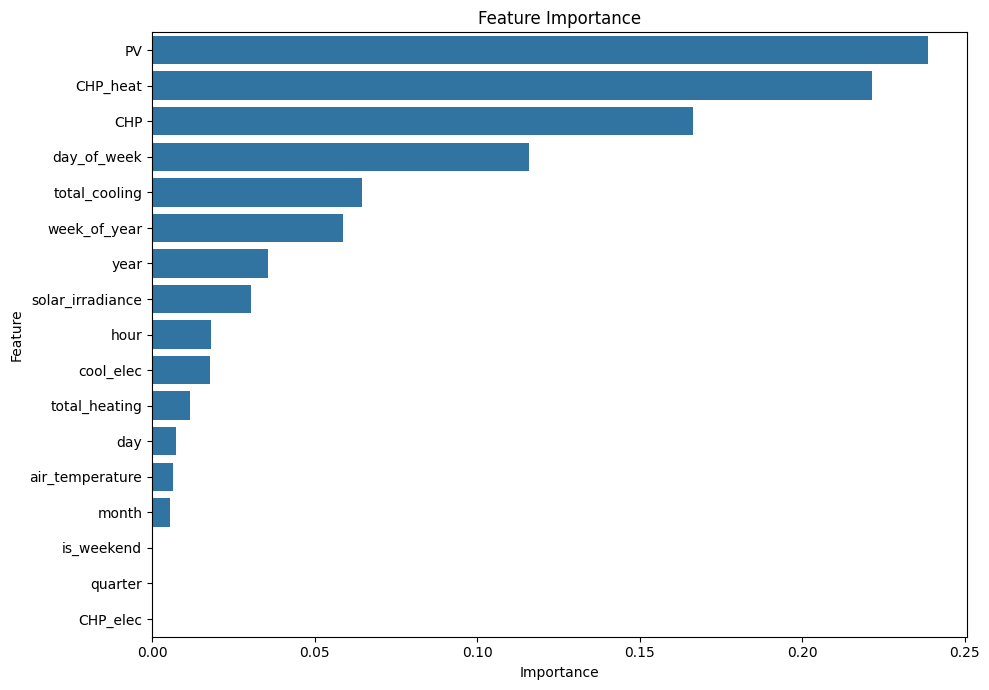

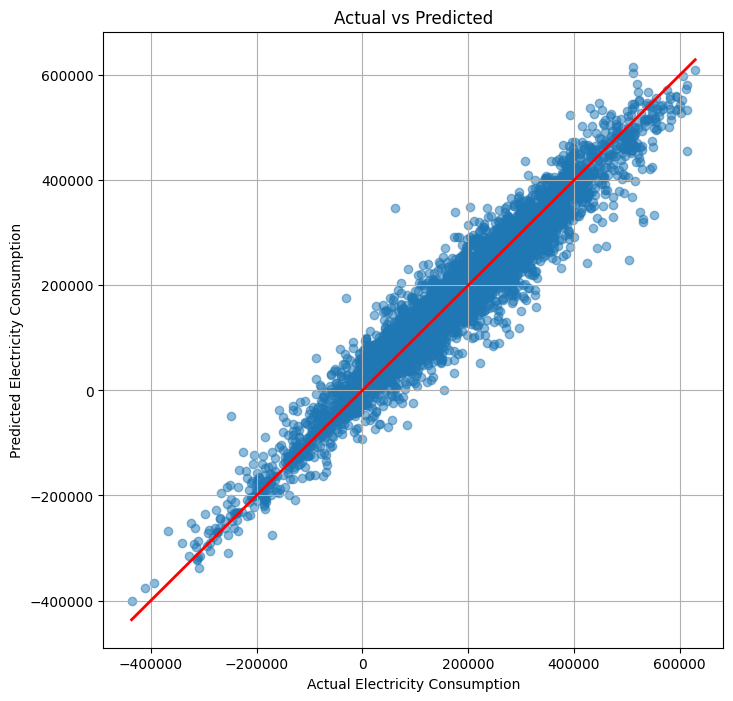

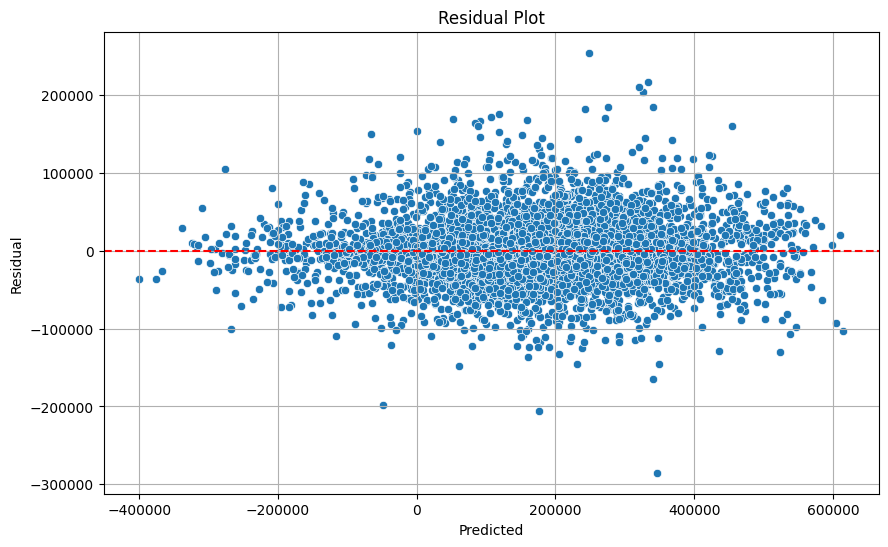

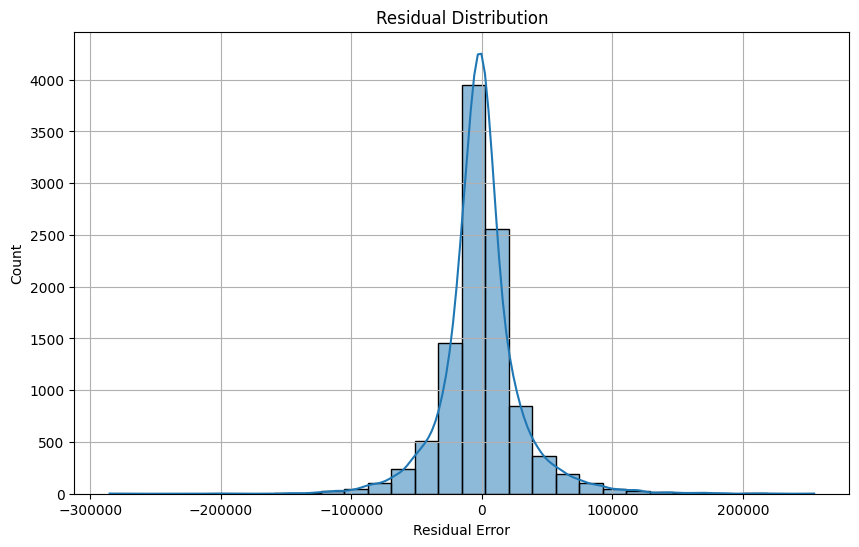

SHAP ANALYSIS
Generating SHAP Summary Plot...


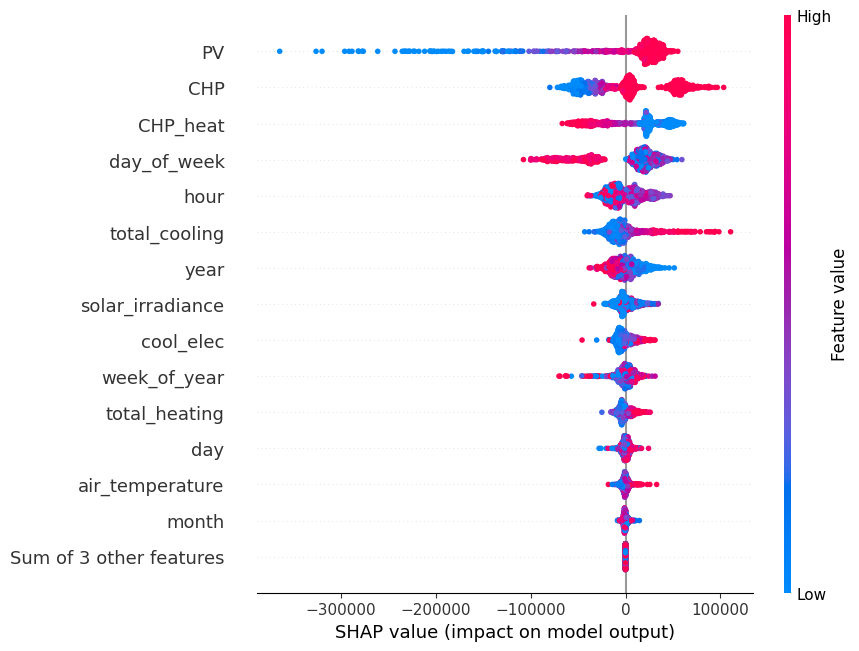

Generating SHAP Feature Importance...


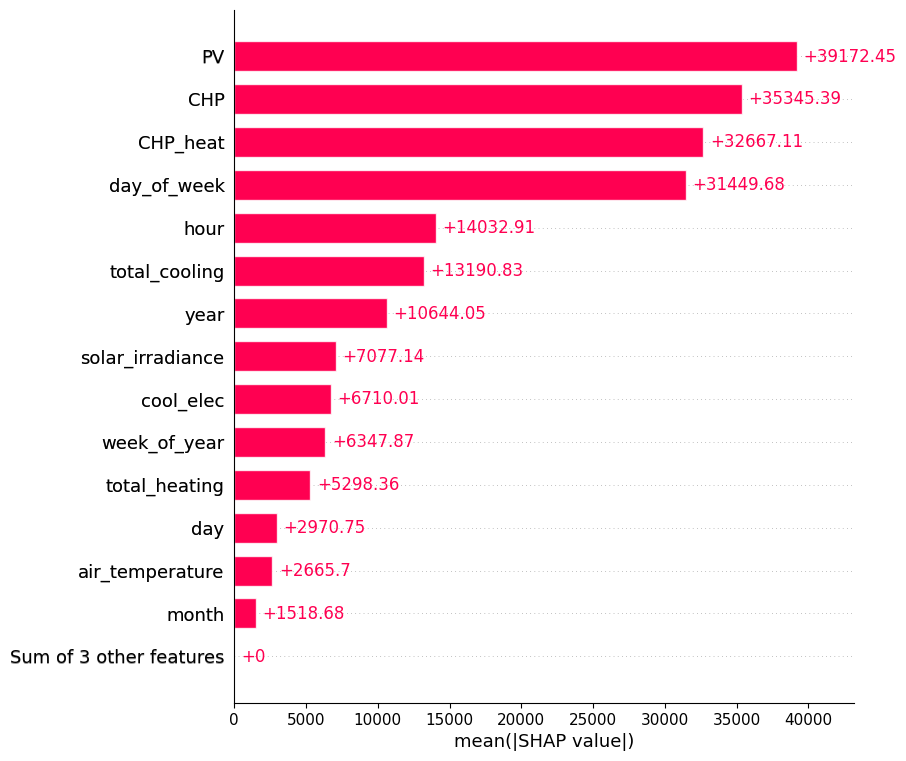

SECONDARY SMART BUILDING MODEL COMPLETED

Saved Files
--------------------------------------------------
secondary_best_model.pkl
secondary_feature_importance.csv
secondary_final_model.pkl
secondary_model_comparison.csv
secondary_predictions.csv
secondary_shap_values.csv
secondary_test_dataset.csv
secondary_train_dataset.csv

Model Name : XGBoost
Prediction Accuracy : 91.77 %
Test R² : 0.9397


In [9]:
# ==========================================================
# SECONDARY SMART BUILDING PREDICTION
# Cell 4
# 16. Feature Importance
# 17. Actual vs Predicted
# 18. Residual Analysis
# 19. SHAP Explainability
# 20. Save Outputs
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns
import shap

print("="*80)
print("MODEL INTERPRETATION")
print("="*80)

# ==========================================================
# Feature Importance
# ==========================================================

if hasattr(final_model, "feature_importances_"):

    importance = pd.DataFrame({

        "Feature":X_train.columns,

        "Importance":final_model.feature_importances_

    })

    importance = importance.sort_values(

        by="Importance",

        ascending=False

    )

    print("="*80)
    print("FEATURE IMPORTANCE")
    print("="*80)

    display(importance)

    importance.to_csv(

        os.path.join(
            MODEL_DIR,
            "secondary_feature_importance.csv"
        ),

        index=False

    )

    plt.figure(figsize=(10,7))

    sns.barplot(

        data=importance,

        x="Importance",

        y="Feature"

    )

    plt.title("Feature Importance")

    plt.tight_layout()

    plt.show()

# ==========================================================
# Actual vs Predicted
# ==========================================================

plt.figure(figsize=(8,8))

plt.scatter(

    y_test,

    prediction,

    alpha=0.5

)

plt.plot(

    [y_test.min(),y_test.max()],

    [y_test.min(),y_test.max()],

    color="red",

    linewidth=2

)

plt.xlabel("Actual Electricity Consumption")

plt.ylabel("Predicted Electricity Consumption")

plt.title("Actual vs Predicted")

plt.grid(True)

plt.show()

# ==========================================================
# Residual Plot
# ==========================================================

residuals = y_test - prediction

plt.figure(figsize=(10,6))

sns.scatterplot(

    x=prediction,

    y=residuals

)

plt.axhline(

    y=0,

    color="red",

    linestyle="--"

)

plt.xlabel("Predicted")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.grid(True)

plt.show()

# ==========================================================
# Error Distribution
# ==========================================================

plt.figure(figsize=(10,6))

sns.histplot(

    residuals,

    bins=30,

    kde=True

)

plt.title("Residual Distribution")

plt.xlabel("Residual Error")

plt.grid(True)

plt.show()

# ==========================================================
# SHAP Explainability
# ==========================================================

print("="*80)
print("SHAP ANALYSIS")
print("="*80)

sample = X_test.sample(

    min(1000,len(X_test)),

    random_state=42

)

explainer = shap.TreeExplainer(final_model)

shap_values = explainer(sample)

print("Generating SHAP Summary Plot...")

shap.plots.beeswarm(

    shap_values,

    max_display=15

)

print("Generating SHAP Feature Importance...")

shap.plots.bar(

    shap_values,

    max_display=15

)

# ==========================================================
# Save SHAP Values
# ==========================================================

shap_df = pd.DataFrame(

    shap_values.values,

    columns=sample.columns

)

shap_df.to_csv(

    os.path.join(

        MODEL_DIR,

        "secondary_shap_values.csv"

    ),

    index=False

)

# ==========================================================
# Save Final Model Again
# ==========================================================

joblib.dump(

    final_model,

    os.path.join(

        MODEL_DIR,

        "secondary_final_model.pkl"

    )

)

# ==========================================================
# Summary
# ==========================================================

print("="*80)
print("SECONDARY SMART BUILDING MODEL COMPLETED")
print("="*80)

print("\nSaved Files")

print("-"*50)

for file in os.listdir(MODEL_DIR):

    if "secondary" in file.lower():

        print(file)

print("\nModel Name :", best_model_name)

print("Prediction Accuracy :", round(accuracy,2),"%")

print("Test R² :", round(tuned_df.iloc[0]["Test R2"],4))

print("="*80)